# Analyse Library Usage in Agent-Authored PRs

This notebook analyses how AI coding agents use external libraries in their pull requests.

Research Questions:
1. Do agents happily import and install new libraries?
2. Do they willingly use external libraries that are already installed or do they avoid it?
3. Do they try to commit invalid libraries?
4. Do they specify library versions in their PRs?
5. What are the most common libraries used by agents?

In [1]:
import sys

sys.path.append("..")

import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm

from src.pr_analyzer import PRAnalyzer

warnings.filterwarnings("ignore")

tqdm.pandas()

data_dir = Path("../data")
output_dir = Path("../output")
output_dir.mkdir(exist_ok=True)

## Load Data

We'll use the filtered PR data from the language exploration notebook.

In [2]:
# Load the datasets
print("Loading datasets...")
pr_df = pd.read_parquet(data_dir / "top5_languages_prs.parquet")
print(pr_df.columns.tolist())
commit_details_df = pd.read_parquet(data_dir / "pr_commit_details.parquet")

print(f"Pull Requests (top 5 languages): {len(pr_df):,}")
print(f"Languages: {sorted(pr_df['language_analysis'].unique())}")
print(f"Commit Details: {len(commit_details_df):,}")

Loading datasets...
['id', 'number', 'title', 'body', 'agent', 'user_id', 'user', 'state', 'created_at', 'closed_at', 'merged_at', 'repo_id', 'repo_url', 'html_url', 'language', 'language_analysis']
Pull Requests (top 5 languages): 27,853
Languages: ['csharp', 'go', 'python', 'rust', 'typescript']
Commit Details: 711,923


## Prepare Data for Analysis

In [3]:
# Get the unique analysis languages
analysis_langs = sorted(pr_df["language_analysis"].unique())
print(f"Languages to analyse: {analysis_langs}")

# Get PR and repo counts by language
lang_pr_counts = pr_df["language_analysis"].value_counts()
lang_repo_counts = pr_df.groupby("language_analysis")["repo_id"].nunique()

print("\nPR and repo counts by language:")
for lang in analysis_langs:
    pr_count = lang_pr_counts[lang]
    repo_count = lang_repo_counts[lang]
    print(f"  {lang}: {repo_count:,} repos, {pr_count:,} PRs")

# Filter commit details to only include PRs in our dataset
pr_ids = set(pr_df["id"])
top_commits = commit_details_df[commit_details_df["pr_id"].isin(pr_ids)].copy()

# Rename pr_id to pull_request_id for compatibility with PRAnalyser
top_commits = top_commits.rename(columns={"pr_id": "pull_request_id"})

# Add repo_id and agent columns from pr_df for the analyser
pr_info = pr_df[["id", "repo_id", "agent"]].rename(columns={"id": "pull_request_id"})
top_commits = top_commits.merge(pr_info, on="pull_request_id", how="left")

print(f"\nCommit details for analysis: {len(top_commits):,}")

Languages to analyse: ['csharp', 'go', 'python', 'rust', 'typescript']

PR and repo counts by language:
  csharp: 220 repos, 1,985 PRs
  go: 242 repos, 10,108 PRs
  python: 530 repos, 7,191 PRs
  rust: 159 repos, 1,079 PRs
  typescript: 840 repos, 7,490 PRs

Commit details for analysis: 586,764


## Analyse Library Usage by Language

In [4]:
analyser = PRAnalyzer()
results_by_language = {}

for lang in analysis_langs:
    print(f"\n{'=' * 60}")
    print(f"Analysing {lang}...")
    print("=" * 60)

    # Get PRs for this language
    lang_pr_ids = set(pr_df[pr_df["language_analysis"] == lang]["id"])
    lang_commits = top_commits[top_commits["pull_request_id"].isin(lang_pr_ids)]

    print(f"PRs: {len(lang_pr_ids):,}")
    print(f"File changes: {len(lang_commits):,}")

    # Analyse
    print("\nAnalysing library usage...")
    results = analyser.analyse_commit_details(lang_commits, lang)

    results_by_language[lang] = list(results.values())
    print(f"Analysed {len(results):,} PRs")


Analysing csharp...
PRs: 1,985
File changes: 60,471

Analysing library usage...
Analysed 1,983 PRs

Analysing go...
PRs: 10,108
File changes: 182,144

Analysing library usage...
Analysed 10,107 PRs

Analysing python...
PRs: 7,191
File changes: 91,031

Analysing library usage...
Analysed 7,190 PRs

Analysing rust...
PRs: 1,079
File changes: 21,066

Analysing library usage...
Analysed 1,079 PRs

Analysing typescript...
PRs: 7,490
File changes: 232,052

Analysing library usage...
Analysed 7,480 PRs


## Generate Statistics

In [5]:
stats_by_language = {}

for lang, usages in results_by_language.items():
    print(f"\n{'=' * 70}")
    print(f"{lang.upper()} STATISTICS")
    print("=" * 70)

    stats = PRAnalyzer.aggregate_statistics(usages)
    stats_by_language[lang] = stats

    # Get repo count for this language
    repo_count = lang_repo_counts[lang]

    # General Stats
    print("\n--- General Stats ---")
    print(f"Number of repos: {repo_count:,}")
    print(f"Number of PRs: {stats['total_prs']:,}")

    # RQ1: Library Usage
    print("\n--- RQ1: Library Usage ---")
    print(
        f"% of PRs with stdlib import: {stats['pct_prs_with_stdlib']:.1f}% ({stats['prs_with_stdlib']:,} PRs)"
    )
    print(
        f"% of PRs with external library import: {stats['pct_prs_with_extlib']:.1f}% ({stats['prs_with_extlib']:,} PRs)"
    )
    print(f"Average stdlib imports per PR: {stats['avg_stdlib_per_pr']:.2f}")
    print(f"Average external library imports per PR: {stats['avg_extlib_per_pr']:.2f}")

    # RQ2: New Dependencies
    print("\n--- RQ2: New Dependencies ---")
    print(
        f"% of PRs with new dependency: {stats['pct_prs_with_new_deps']:.1f}% ({stats['prs_with_new_deps']:,} PRs)"
    )
    print(f"Average new dependencies per PR: {stats['avg_new_deps_per_pr']:.2f}")
    print(
        f"% of new dependencies with version: {stats['pct_new_deps_with_version']:.1f}%"
    )
    print(f"Total unique new dependencies: {stats['total_unique_new_deps']:,}")

    # RQ3: Choosing Libraries
    print("\n--- RQ3: Choosing Libraries (Top 20 New Dependencies) ---")
    print(f"{'Dependency':<30} {'Count':>8} {'% of PRs':>10}")
    print("-" * 50)
    for lib, count, pct in stats["top_new_deps"]:
        print(f"{lib:<30} {count:>8,} {pct:>9.1f}%")


CSHARP STATISTICS

--- General Stats ---
Number of repos: 220
Number of PRs: 1,983

--- RQ1: Library Usage ---
% of PRs with stdlib import: 37.5% (743 PRs)
% of PRs with external library import: 37.4% (742 PRs)
Average stdlib imports per PR: 0.49
Average external library imports per PR: 0.79

--- RQ2: New Dependencies ---
% of PRs with new dependency: 6.6% (131 PRs)
Average new dependencies per PR: 0.30
% of new dependencies with version: 46.0%
Total unique new dependencies: 295

--- RQ3: Choosing Libraries (Top 20 New Dependencies) ---
Dependency                        Count   % of PRs
--------------------------------------------------
Microsoft.NET.Test.Sdk               26       1.3%
xunit.runner.visualstudio            22       1.1%
Moq                                  20       1.0%
xunit                                20       1.0%
coverlet.collector                   15       0.8%
Microsoft.AspNetCore.Mvc.Testing       11       0.6%
StaticViewLocator                    11       

## Visualisations

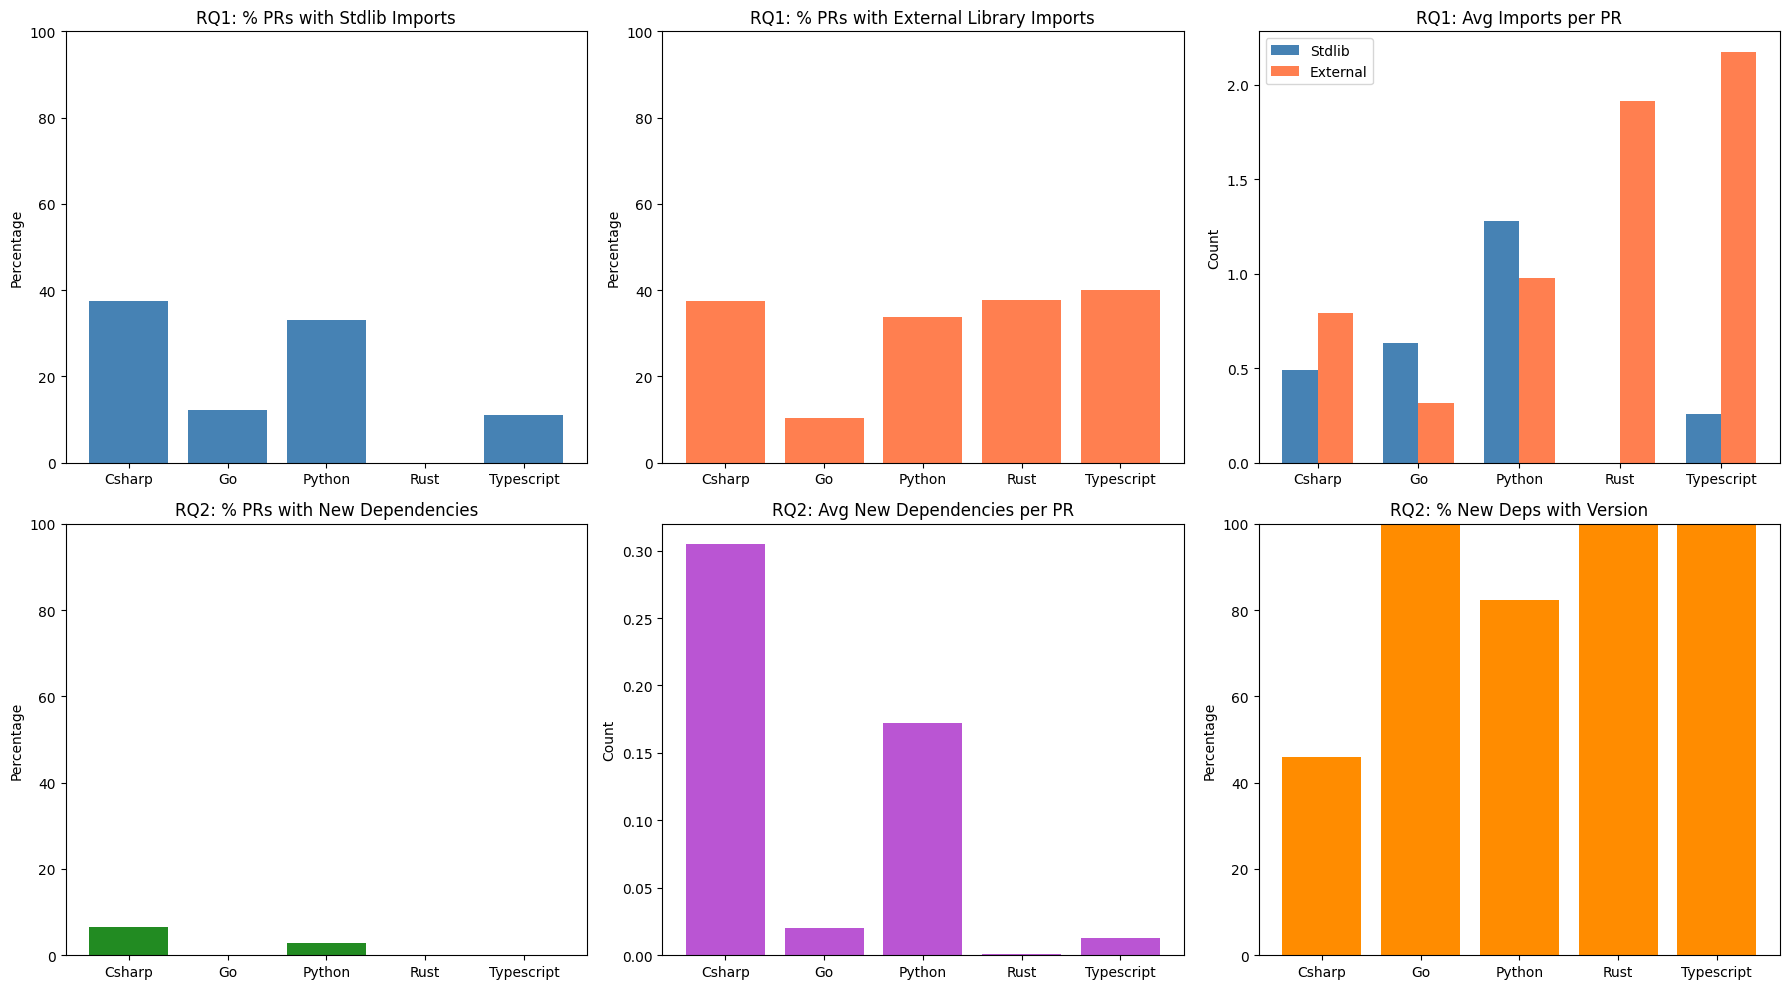

Saved visualisations:
  - ../output/library_usage_by_rq.png (combined)
  - ../output/rq1_library_usage.png
  - ../output/rq2_new_dependencies.png


In [6]:
# Library usage comparison across languages - organized by RQs
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

langs = list(stats_by_language.keys())
lang_labels = [lang.capitalize() for lang in langs]

# RQ1: Library Usage
# 1. % PRs with stdlib imports
pct_stdlib = [stats_by_language[lang]["pct_prs_with_stdlib"] for lang in langs]
axes[0, 0].bar(lang_labels, pct_stdlib, color="steelblue")
axes[0, 0].set_title("RQ1: % PRs with Stdlib Imports")
axes[0, 0].set_ylabel("Percentage")
axes[0, 0].set_ylim([0, 100])

# 2. % PRs with external library imports
pct_extlib = [stats_by_language[lang]["pct_prs_with_extlib"] for lang in langs]
axes[0, 1].bar(lang_labels, pct_extlib, color="coral")
axes[0, 1].set_title("RQ1: % PRs with External Library Imports")
axes[0, 1].set_ylabel("Percentage")
axes[0, 1].set_ylim([0, 100])

# 3. Average imports per PR (stdlib vs extlib)
avg_stdlib = [stats_by_language[lang]["avg_stdlib_per_pr"] for lang in langs]
avg_extlib = [stats_by_language[lang]["avg_extlib_per_pr"] for lang in langs]
x = range(len(langs))
width = 0.35
axes[0, 2].bar(
    [i - width / 2 for i in x], avg_stdlib, width, label="Stdlib", color="steelblue"
)
axes[0, 2].bar(
    [i + width / 2 for i in x], avg_extlib, width, label="External", color="coral"
)
axes[0, 2].set_xticks(x)
axes[0, 2].set_xticklabels(lang_labels)
axes[0, 2].set_title("RQ1: Avg Imports per PR")
axes[0, 2].set_ylabel("Count")
axes[0, 2].legend()

# RQ2: New Dependencies
# 4. % PRs with new dependencies
pct_new_deps = [stats_by_language[lang]["pct_prs_with_new_deps"] for lang in langs]
axes[1, 0].bar(lang_labels, pct_new_deps, color="forestgreen")
axes[1, 0].set_title("RQ2: % PRs with New Dependencies")
axes[1, 0].set_ylabel("Percentage")
axes[1, 0].set_ylim([0, 100])

# 5. Average new dependencies per PR
avg_new_deps = [stats_by_language[lang]["avg_new_deps_per_pr"] for lang in langs]
axes[1, 1].bar(lang_labels, avg_new_deps, color="mediumorchid")
axes[1, 1].set_title("RQ2: Avg New Dependencies per PR")
axes[1, 1].set_ylabel("Count")

# 6. % new deps with version
pct_with_ver = [stats_by_language[lang]["pct_new_deps_with_version"] for lang in langs]
axes[1, 2].bar(lang_labels, pct_with_ver, color="darkorange")
axes[1, 2].set_title("RQ2: % New Deps with Version")
axes[1, 2].set_ylabel("Percentage")
axes[1, 2].set_ylim([0, 100])

plt.tight_layout()
plt.savefig(output_dir / "library_usage_by_rq.png", dpi=300, bbox_inches="tight")
plt.show()

# Save individual RQ visualisations
# RQ1: Library Usage - 3 charts
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))

axes1[0].bar(lang_labels, pct_stdlib, color="steelblue")
axes1[0].set_title("% PRs with Stdlib Imports")
axes1[0].set_ylabel("Percentage")
axes1[0].set_ylim([0, 100])

axes1[1].bar(lang_labels, pct_extlib, color="coral")
axes1[1].set_title("% PRs with External Library Imports")
axes1[1].set_ylabel("Percentage")
axes1[1].set_ylim([0, 100])

axes1[2].bar(
    [i - width / 2 for i in x], avg_stdlib, width, label="Stdlib", color="steelblue"
)
axes1[2].bar(
    [i + width / 2 for i in x], avg_extlib, width, label="External", color="coral"
)
axes1[2].set_xticks(x)
axes1[2].set_xticklabels(lang_labels)
axes1[2].set_title("Avg Imports per PR")
axes1[2].set_ylabel("Count")
axes1[2].legend()

plt.tight_layout()
plt.savefig(output_dir / "rq1_library_usage.png", dpi=300, bbox_inches="tight")
plt.close()

# RQ2: New Dependencies - 3 charts
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))

axes2[0].bar(lang_labels, pct_new_deps, color="forestgreen")
axes2[0].set_title("% PRs with New Dependencies")
axes2[0].set_ylabel("Percentage")
axes2[0].set_ylim([0, 100])

axes2[1].bar(lang_labels, avg_new_deps, color="mediumorchid")
axes2[1].set_title("Avg New Dependencies per PR")
axes2[1].set_ylabel("Count")

axes2[2].bar(lang_labels, pct_with_ver, color="darkorange")
axes2[2].set_title("% New Deps with Version")
axes2[2].set_ylabel("Percentage")
axes2[2].set_ylim([0, 100])

plt.tight_layout()
plt.savefig(output_dir / "rq2_new_dependencies.png", dpi=300, bbox_inches="tight")
plt.close()

print("Saved visualisations:")
print(f"  - {output_dir / 'library_usage_by_rq.png'} (combined)")
print(f"  - {output_dir / 'rq1_library_usage.png'}")
print(f"  - {output_dir / 'rq2_new_dependencies.png'}")

## Save Results

In [8]:
# Save detailed results
for lang, usages in results_by_language.items():
    # Convert to list of dicts
    results_list = [u.to_dict() for u in usages]

    # Save as JSON
    output_file = output_dir / f"results_{lang}.json"
    with open(output_file, "w") as f:
        json.dump(results_list, f, indent=2)
    print(f"Saved {lang} results to {output_file}")

# Save aggregated statistics
stats_file = output_dir / "aggregated_statistics.json"
# Convert list of tuples to dicts for JSON serialisation
stats_serialisable = {}
for lang, stats in stats_by_language.items():
    stats_copy = stats.copy()
    # Convert Counter.most_common() results (list of tuples) to dicts
    if "most_common_stdlib" in stats_copy:
        stats_copy["most_common_stdlib"] = dict(stats_copy["most_common_stdlib"])
    if "most_common_extlib" in stats_copy:
        stats_copy["most_common_extlib"] = dict(stats_copy["most_common_extlib"])
    # Convert top_new_deps (list of tuples with 3 elements) to list of dicts
    if "top_new_deps" in stats_copy:
        stats_copy["top_new_deps"] = [
            {"library": lib, "count": count, "pct_of_prs": pct}
            for lib, count, pct in stats_copy["top_new_deps"]
        ]
    stats_serialisable[lang] = stats_copy

with open(stats_file, "w") as f:
    json.dump(stats_serialisable, f, indent=2)
print(f"\nSaved aggregated statistics to {stats_file}")

Saved csharp results to ../output/results_csharp.json
Saved go results to ../output/results_go.json
Saved python results to ../output/results_python.json
Saved rust results to ../output/results_rust.json
Saved typescript results to ../output/results_typescript.json

Saved aggregated statistics to ../output/aggregated_statistics.json


## Summary of Findings

This section will be updated after running the analysis with key insights about:

1. **Library Adoption**: Do agents readily add new libraries?
2. **Existing Libraries**: Do agents use already-installed libraries or avoid dependencies?
3. **Version Specifications**: How often do agents specify versions?
4. **Most Common Libraries**: What are the go-to libraries for each language?
5. **Invalid Libraries**: Pattern detection for potentially invalid dependencies